# imports

In [55]:
!pip install -q matplotlib

In [56]:
%reload_ext autoreload
%autoreload 2

import torch
import sys
import os
from torchmetrics.functional.pairwise import pairwise_cosine_similarity
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt

# local imports
sys.path.insert(
    0,
    os.path.join(
        (os.path.dirname(os.path.abspath(''))),
    )
)
from evaluation.bright.retrievers import (
    get_scores,
    calculate_retrieval_metrics
)
sys.path.pop(0)


PKLS_PATH = os.path.join(os.path.dirname(os.path.abspath('')), 'evaluation', 'bright')
SEPARATION_ID = 45

# functions

In [39]:
def compute_results(
    query_emb,
    doc_emb,
    documents,
    ground_truth,
    query_ids,
    doc_ids,
    excluded_ids,
    separation_id=None,
    projection_matrix=None
):
    if separation_id is not None:
        query_emb = query_emb[:separation_id]
        query_ids = query_ids[:separation_id]

    if projection_matrix is not None:
        query_emb = query_emb @ projection_matrix

    scores = pairwise_cosine_similarity(torch.from_numpy(query_emb), torch.from_numpy(doc_emb))
    scores = scores.tolist()
    assert len(scores) == len(query_ids), f"{len(scores)}, {len(query_ids)}"
    assert len(scores[0]) == len(documents), f"{len(scores[0])}, {len(documents)}"
    final_scores = get_scores(query_ids=query_ids,doc_ids=doc_ids,scores=scores,excluded_ids=excluded_ids)
    results = calculate_retrieval_metrics(results=final_scores, qrels=ground_truth)
    # print(results)
    return results


def least_squares_projection(X, Y):
    """
    Perform least squares projection of Y onto X
    """
    # Ensure X and Y are numpy arrays
    # Get training data from indices after SEPARATION_ID

    # Solve for projection matrix using least squares
    # X @ W = Y
    # W = (X^T X)^-1 X^T Y
    W = np.linalg.lstsq(X, Y, rcond=None)[0]

    # print(W.shape)  # Should be (base_dim, reason_dim)
    return W


# reproduce numbers

In [9]:
doc_ids, query_ids, excluded_ids = torch.load(os.path.join(PKLS_PATH, 'ids.pkl'))
documents, doc_emb = torch.load(os.path.join(PKLS_PATH, 'base_doc_emb.pkl'))
queries_base, query_emb_base = torch.load(os.path.join(PKLS_PATH, 'base_emb.pkl'))
queries_reason, query_emb_reason = torch.load(os.path.join(PKLS_PATH, 'reason_emb.pkl'))
ground_truth = torch.load(os.path.join(PKLS_PATH, 'ground_truth.pkl'))

In [ ]:
results_base = compute_results(
    query_emb=query_emb_base,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids
)

{'NDCG@1': 0.19737, 'NDCG@5': 0.25338, 'NDCG@10': 0.27224, 'NDCG@25': 0.29811, 'NDCG@50': 0.31211, 'NDCG@100': 0.33633, 'MAP@1': 0.10746, 'MAP@5': 0.21089, 'MAP@10': 0.22015, 'MAP@25': 0.22732, 'MAP@50': 0.22926, 'MAP@100': 0.23172, 'Recall@1': 0.10746, 'Recall@5': 0.30279, 'Recall@10': 0.35542, 'Recall@25': 0.45849, 'Recall@50': 0.5177, 'Recall@100': 0.6391, 'P@1': 0.19737, 'P@5': 0.11579, 'P@10': 0.06711, 'P@25': 0.03211, 'P@50': 0.01868, 'P@100': 0.01197, 'MRR': 0.29551, 'Oracle NDCG@1': 0.77632, 'Oracle NDCG@5': 0.67497, 'Oracle NDCG@10': 0.6728, 'Oracle NDCG@25': 0.67467, 'Oracle NDCG@50': 0.67467, 'Oracle NDCG@100': 0.67909}


In [49]:
results_base_short = compute_results(
    query_emb=query_emb_base,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids,
    separation_id=SEPARATION_ID
)

{'NDCG@1': 0.22222, 'NDCG@5': 0.26337, 'NDCG@10': 0.28566, 'NDCG@25': 0.32147, 'NDCG@50': 0.33993, 'NDCG@100': 0.36304, 'MAP@1': 0.12593, 'MAP@5': 0.22481, 'MAP@10': 0.23499, 'MAP@25': 0.24538, 'MAP@50': 0.24778, 'MAP@100': 0.25015, 'Recall@1': 0.12593, 'Recall@5': 0.30741, 'Recall@10': 0.37037, 'Recall@25': 0.51481, 'Recall@50': 0.59259, 'Recall@100': 0.70741, 'P@1': 0.22222, 'P@5': 0.10667, 'P@10': 0.06222, 'P@25': 0.032, 'P@50': 0.01956, 'P@100': 0.01244, 'MRR': 0.31505, 'Oracle NDCG@1': 0.82222, 'Oracle NDCG@5': 0.73886, 'Oracle NDCG@10': 0.73886, 'Oracle NDCG@25': 0.74201, 'Oracle NDCG@50': 0.74201, 'Oracle NDCG@100': 0.74799}


In [ ]:
results_reason = compute_results(
    query_emb=query_emb_reason,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids
)

{'NDCG@1': 0.31579, 'NDCG@5': 0.34635, 'NDCG@10': 0.36869, 'NDCG@25': 0.39197, 'NDCG@50': 0.41933, 'NDCG@100': 0.42691, 'MAP@1': 0.18061, 'MAP@5': 0.30298, 'MAP@10': 0.31194, 'MAP@25': 0.31989, 'MAP@50': 0.32471, 'MAP@100': 0.3256, 'Recall@1': 0.18061, 'Recall@5': 0.38941, 'Recall@10': 0.46178, 'Recall@25': 0.54151, 'Recall@50': 0.65962, 'Recall@100': 0.6969, 'P@1': 0.31579, 'P@5': 0.15, 'P@10': 0.08553, 'P@25': 0.04053, 'P@50': 0.025, 'P@100': 0.01329, 'MRR': 0.39604, 'Oracle NDCG@1': 0.82895, 'Oracle NDCG@5': 0.73188, 'Oracle NDCG@10': 0.72938, 'Oracle NDCG@25': 0.73255, 'Oracle NDCG@50': 0.73485, 'Oracle NDCG@100': 0.73485}


In [50]:
results_reason_short = compute_results(
    query_emb=query_emb_reason,
    doc_emb=doc_emb,
    documents=documents,
    ground_truth=ground_truth,
    query_ids=query_ids,
    doc_ids=doc_ids,
    excluded_ids=excluded_ids,
    separation_id=SEPARATION_ID
)

{'NDCG@1': 0.26667, 'NDCG@5': 0.3224, 'NDCG@10': 0.34592, 'NDCG@25': 0.37794, 'NDCG@50': 0.40355, 'NDCG@100': 0.41251, 'MAP@1': 0.15741, 'MAP@5': 0.27231, 'MAP@10': 0.28071, 'MAP@25': 0.29198, 'MAP@50': 0.296, 'MAP@100': 0.29692, 'Recall@1': 0.15741, 'Recall@5': 0.39074, 'Recall@10': 0.46481, 'Recall@25': 0.57778, 'Recall@50': 0.68704, 'Recall@100': 0.73333, 'P@1': 0.26667, 'P@5': 0.13778, 'P@10': 0.07778, 'P@25': 0.03911, 'P@50': 0.024, 'P@100': 0.01289, 'MRR': 0.37065, 'Oracle NDCG@1': 0.84444, 'Oracle NDCG@5': 0.76382, 'Oracle NDCG@10': 0.76382, 'Oracle NDCG@25': 0.76917, 'Oracle NDCG@50': 0.77305, 'Oracle NDCG@100': 0.77305}


# learn projections

In [51]:
Ws = []
for i in tqdm(range(SEPARATION_ID, query_emb_base.shape[0])):
    Ws.append((i, least_squares_projection(query_emb_base[i:], query_emb_reason[i:])))



100%|██████████| 31/31 [00:53<00:00,  1.74s/it]


In [57]:
ndcgs_at_10 = []
for i, W in Ws:
    print(f"Results for {query_emb_base.shape[0] - i} test embeddings:")
    results_base_short_with_proj = compute_results(
        query_emb=query_emb_base,
        doc_emb=doc_emb,
        documents=documents,
        ground_truth=ground_truth,
        query_ids=query_ids,
        doc_ids=doc_ids,
        excluded_ids=excluded_ids,
        separation_id=SEPARATION_ID,
        projection_matrix=W
    )
    ndcgs_at_10.append(results_base_short_with_proj['NDCG@10'])

    # print(results_base_short_with_proj)
    print("\n")


Results for 31 test embeddings:
{'NDCG@1': 0.11111, 'NDCG@5': 0.14892, 'NDCG@10': 0.16505, 'NDCG@25': 0.17888, 'NDCG@50': 0.19403, 'NDCG@100': 0.20264, 'MAP@1': 0.05185, 'MAP@5': 0.1237, 'MAP@10': 0.13148, 'MAP@25': 0.13548, 'MAP@50': 0.13758, 'MAP@100': 0.13851, 'Recall@1': 0.05185, 'Recall@5': 0.18148, 'Recall@10': 0.22593, 'Recall@25': 0.28148, 'Recall@50': 0.3463, 'Recall@100': 0.38519, 'P@1': 0.11111, 'P@5': 0.06667, 'P@10': 0.04, 'P@25': 0.01867, 'P@50': 0.012, 'P@100': 0.00711, 'MRR': 0.17648, 'Oracle NDCG@1': 0.48889, 'Oracle NDCG@5': 0.40773, 'Oracle NDCG@10': 0.41788, 'Oracle NDCG@25': 0.42825, 'Oracle NDCG@50': 0.42825, 'Oracle NDCG@100': 0.43034}


Results for 30 test embeddings:
{'NDCG@1': 0.11111, 'NDCG@5': 0.14938, 'NDCG@10': 0.15846, 'NDCG@25': 0.18322, 'NDCG@50': 0.19365, 'NDCG@100': 0.20401, 'MAP@1': 0.05185, 'MAP@5': 0.12407, 'MAP@10': 0.12884, 'MAP@25': 0.13574, 'MAP@50': 0.13705, 'MAP@100': 0.1382, 'Recall@1': 0.05185, 'Recall@5': 0.18148, 'Recall@10': 0.2037, 'Rec

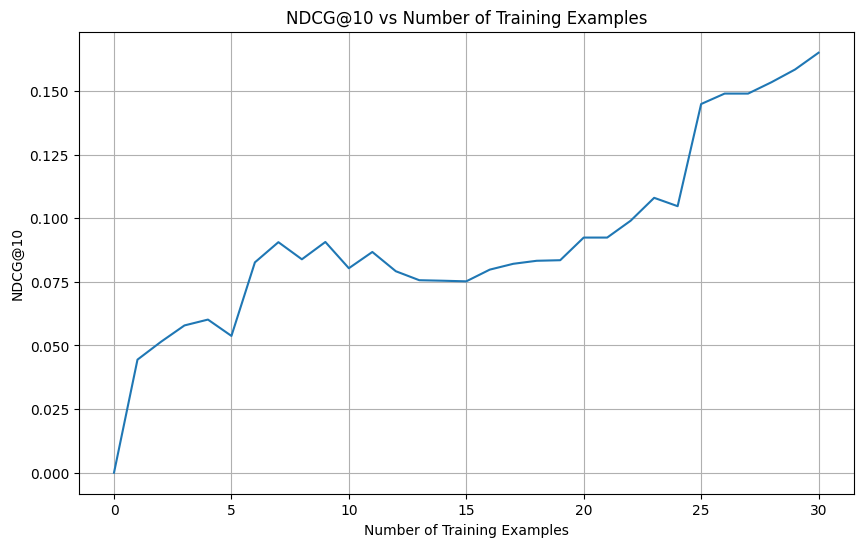

In [59]:
plt.figure(figsize=(10,6))
plt.plot(range(len(ndcgs_at_10))[::-1], ndcgs_at_10)
plt.xlabel('Number of Training Examples')
plt.ylabel('NDCG@10')
plt.title('NDCG@10 vs Number of Training Examples')
plt.grid(True)
plt.show()
